In [1]:
# Basic packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# ML Algorithms (4 MODELS)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Save Model
import joblib


In [2]:
# Step 2 — Load Dataset
# --------------------------

# Dataset must contain:
# 13 FEATURES + 1 TARGET COLUMN (Disease_Type)

df = pd.read_csv("heart.csv")

print("✅ Dataset Loaded Successfully")
print("Shape :", df.shape)
print("\nColumns:")
print(df.columns)



✅ Dataset Loaded Successfully
Shape : (1025, 14)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [3]:
def classify_disease(row):

    # No Disease
    if row["target"] == 0:
        return 0

    # Heart diseases grouping based on clinical pattern
    elif row["cp"] in [2, 3] and row["oldpeak"] < 1:
        return 1   # Angina

    elif row["chol"] > 240 and row["oldpeak"] >= 1:
        return 2   # Coronary Artery Disease

    elif row["cp"] == 3 and row["oldpeak"] > 2:
        return 3   # Myocardial Infarction
    
    else:
        return 4   # Heart Failure


In [4]:
df["Disease_Type"] = df.apply(classify_disease, axis=1)


In [5]:
disease_map = {
    0: "No Disease",
    1: "Angina",
    2: "Coronary Artery Disease",
    3: "Myocardial Infarction",
    4: "Heart Failure"
}

df["Disease_Name"] = df["Disease_Type"].map(disease_map)

df["Disease_Name"].value_counts()


Disease_Name
No Disease                 499
Heart Failure              280
Angina                     182
Coronary Artery Disease     58
Myocardial Infarction        6
Name: count, dtype: int64

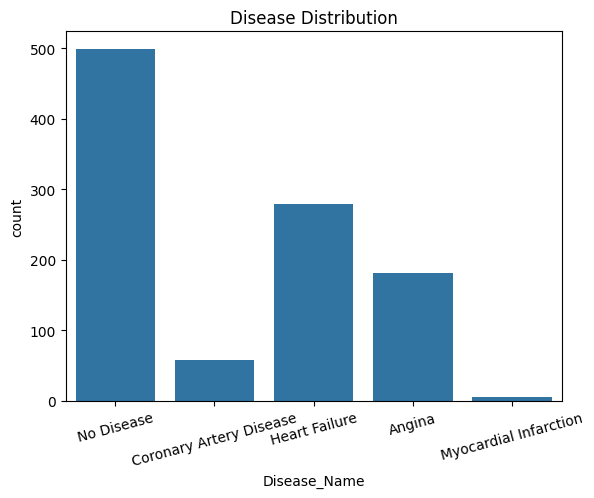

In [6]:
sns.countplot(x="Disease_Name", data=df)
plt.xticks(rotation=15)
plt.title("Disease Distribution")
plt.show()


In [7]:
X = df.drop(columns=["target", "Disease_Name", "Disease_Type"])
y = df["Disease_Type"]


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
# 80% training data, 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),

    "KNN": KNeighborsClassifier(n_neighbors=10),

    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=12,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric="mlogloss",
        use_label_encoder=False
    )
}


In [11]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    results[name] = acc

    print("====================================")
    print(name)
    print("Accuracy:", round(acc * 100, 2), "%")
    print(classification_report(y_test, preds))


Logistic Regression
Accuracy: 78.05 %
              precision    recall  f1-score   support

           0       0.81      0.82      0.82       100
           1       0.85      0.78      0.81        36
           2       0.57      0.33      0.42        12
           3       1.00      1.00      1.00         1
           4       0.71      0.80      0.76        56

    accuracy                           0.78       205
   macro avg       0.79      0.75      0.76       205
weighted avg       0.78      0.78      0.78       205

KNN
Accuracy: 72.68 %
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       100
           1       0.67      0.86      0.76        36
           2       0.00      0.00      0.00        12
           3       0.00      0.00      0.00         1
           4       0.62      0.57      0.59        56

    accuracy                           0.73       205
   macro avg       0.42      0.46      0.44       205
weighted avg     

/home/harshrajsingh035/Heart_Diseases/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/harshrajsingh035/Heart_Diseases/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/harshrajsingh035/Heart_Diseases/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Random Forest
Accuracy: 100.0 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        12
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00        56

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



/home/harshrajsingh035/Heart_Diseases/venv/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [19:21:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
Accuracy: 100.0 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        12
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00        56

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



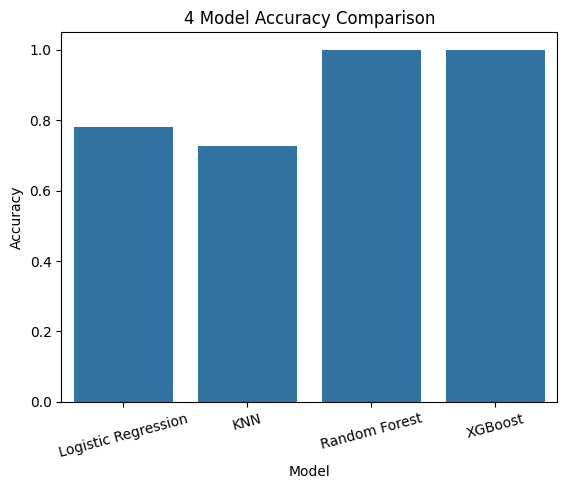

In [12]:
result_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
})

sns.barplot(x="Model", y="Accuracy", data=result_df)
plt.title("4 Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()


In [13]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("✅ BEST MODEL SELECTED:", best_model_name)


✅ BEST MODEL SELECTED: Random Forest


In [14]:
joblib.dump(best_model, "heart_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ MODEL & SCALER SAVED")


✅ MODEL & SCALER SAVED


In [15]:
print("\n🔍 SAMPLE PATIENT DATA FOR EVERY DISEASE TYPE")
print("---------------------------------------------")

for disease, label in disease_map.items():

    print(f"\n==============================")
    print(f"🩺 {label}")
    print("==============================")

    sample_rows = df[df["Disease_Type"] == disease].head(5)

    if sample_rows.empty:
        print("⚠ No sample found for this disease!")
    else:
        display(sample_rows)


🔍 SAMPLE PATIENT DATA FOR EVERY DISEASE TYPE
---------------------------------------------

🩺 No Disease


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Disease_Type,Disease_Name
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,0,No Disease
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,0,No Disease
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,0,No Disease
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,0,No Disease
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,0,No Disease



🩺 Angina


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Disease_Type,Disease_Name
19,58,1,2,140,211,1,0,165,0,0.0,2,0,2,1,1,Angina
23,63,0,2,135,252,0,0,172,0,0.0,2,0,2,1,1,Angina
24,42,0,2,120,209,0,1,173,0,0.0,1,0,2,1,1,Angina
26,44,1,2,130,233,0,1,179,1,0.4,2,0,2,1,1,Angina
34,50,1,2,129,196,0,1,163,0,0.0,2,0,2,1,1,Angina



🩺 Coronary Artery Disease


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Disease_Type,Disease_Name
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1,2,Coronary Artery Disease
16,51,0,2,140,308,0,0,142,0,1.5,2,1,2,1,2,Coronary Artery Disease
18,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1,2,Coronary Artery Disease
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1,2,Coronary Artery Disease
44,55,0,1,132,342,0,1,166,0,1.2,2,0,2,1,2,Coronary Artery Disease



🩺 Myocardial Infarction


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Disease_Type,Disease_Name
389,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,3,Myocardial Infarction
399,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,3,Myocardial Infarction
652,66,0,3,150,226,0,1,114,0,2.6,0,0,2,1,3,Myocardial Infarction
664,66,0,3,150,226,0,1,114,0,2.6,0,0,2,1,3,Myocardial Infarction
713,66,0,3,150,226,0,1,114,0,2.6,0,0,2,1,3,Myocardial Infarction



🩺 Heart Failure


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Disease_Type,Disease_Name
10,71,0,0,112,149,0,1,125,0,1.6,1,0,2,1,4,Heart Failure
12,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1,4,Heart Failure
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1,4,Heart Failure
21,67,0,0,106,223,0,1,142,0,0.3,2,2,2,1,4,Heart Failure
22,45,1,0,104,208,0,0,148,1,3.0,1,0,2,1,4,Heart Failure
